Tomado de: https://www.kaggle.com/code/tharunrajr26/explainable-ai-skin-disease

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [3]:
#Importing required libraries
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import numpy as np
import pandas as pd
import os
from tensorflow.keras.utils import to_categorical
from glob import glob

In [4]:
# Reading the data from HAM_metadata.csv
df = pd.read_csv('../kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

In [ ]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
df.isnull().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,57
sex,0
localization,0


In [ ]:
df.fillna({'age': int(df['age'].mean())}, inplace=True)
df.isnull().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,0
sex,0
localization,0


In [5]:
#Create a dictionary mapping image IDs to file paths

lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

base_skin_dir = '../kaggle/input/skin-cancer-mnist-ham10000'

# Merge images from both folders into one dictionary

imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x
                     for x in glob(os.path.join(base_skin_dir, '*', '*.jpg'))}

In [7]:
df['path'] = df['image_id'].map(imageid_path_dict.get)
df['cell_type'] = df['dx'].map(lesion_type_dict.get)
df['cell_type_idx'] = pd.Categorical(df['cell_type']).codes
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../kaggle/input/skin-cancer-mnist-ham10000/ham...,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../kaggle/input/skin-cancer-mnist-ham10000/ham...,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../kaggle/input/skin-cancer-mnist-ham10000/ham...,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../kaggle/input/skin-cancer-mnist-ham10000/ham...,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../kaggle/input/skin-cancer-mnist-ham10000/ham...,Benign keratosis-like lesions,2


In [20]:
class_names= df['cell_type'].unique().tolist()
class_names

['Benign keratosis-like lesions ',
 'Melanocytic nevi',
 'Dermatofibroma',
 'Melanoma',
 'Vascular lesions',
 'Basal cell carcinoma',
 'Actinic keratoses']

In [8]:
df['image'] = df['path'].map(lambda x: np.asarray(Image.open(x).resize((100,75))))

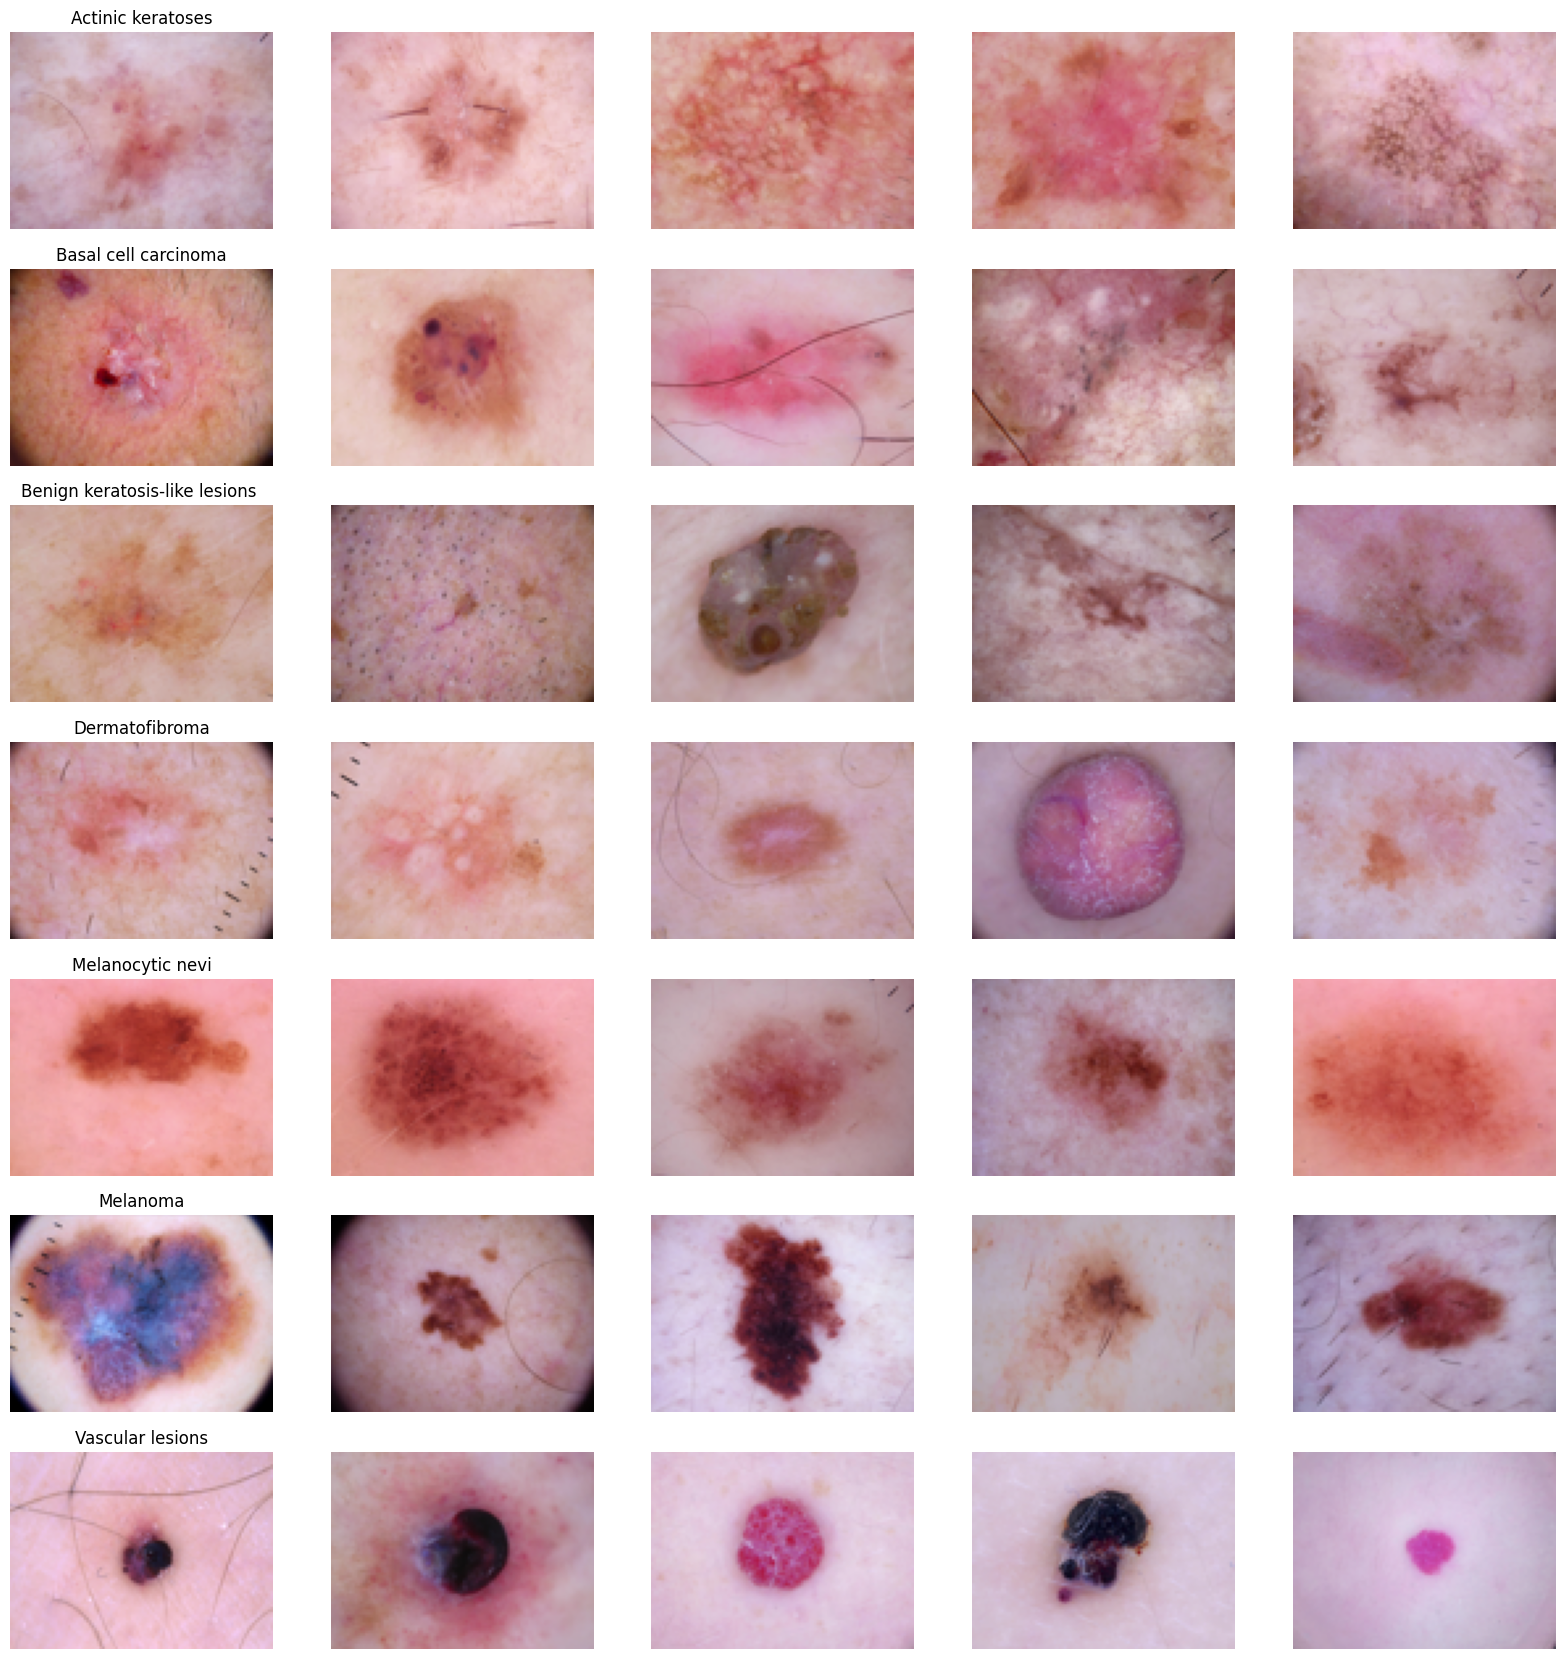

In [9]:
n_samples = 5
fig, m_axs = plt.subplots(7, n_samples, figsize = (4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs, df.sort_values(['cell_type']).groupby('cell_type')):
    n_axs[0].set_title(type_name)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=2018).iterrows()):
        c_ax.imshow(c_row['image'])
        c_ax.axis('off')
fig.savefig('category_samples.png', dpi=300)

In [10]:
import cv2
import numpy as np

def hair_removal(img):
    # Convert to gray
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Kernel for black-hat
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    # Threshold to detect hair
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    # Inpaint to remove hair
    result = cv2.inpaint(img, mask, 1, cv2.INPAINT_TELEA)
    return result

In [11]:
def noise_removal(img):
    return cv2.GaussianBlur(img, (7, 7), 0)

In [12]:
def grabcut_segmentation(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h,s,v = cv2.split(hsv)

    # Lesion appears darker-green-ish region
    _, mask = cv2.threshold(s, 0, 255, cv2.THRESH_OTSU)

    # If mask > 70% of pixels -> use rectangle
    if mask.sum() / 255 > img.size * 0.7:
        h, w = img.shape[:2]
        rect = (int(0.15*w), int(0.15*h), int(0.7*w), int(0.7*h))

        bg = np.zeros((1,65), np.float64)
        fg = np.zeros((1,65), np.float64)
        mask_gc = np.zeros((h,w), np.uint8)

        cv2.grabCut(img, mask_gc, rect, bg, fg, 5, cv2.GC_INIT_WITH_RECT)
        mask_final = np.where((mask_gc==cv2.GC_FGD) | (mask_gc==cv2.GC_PR_FGD), 1, 0).astype("uint8")
    else:
        mask_final = mask//255

    segmented = img * mask_final[:,:,None]
    return segmented

In [13]:
from skimage.feature.texture import graycomatrix, graycoprops

def extract_features(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(gray, [1], [0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]
    entropy_val = np.sum(-glcm*np.log2(glcm + 1e-8))
    corr = graycoprops(glcm, 'correlation')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

    mean = img.mean()
    var = img.var()
    std = img.std()
    rms = np.sqrt(np.mean(np.square(img)))

    return [contrast, energy, entropy_val, corr, homogeneity, mean, var, std, rms]

In [14]:
def process_image(img):
    img1 = hair_removal(img)
    img2 = noise_removal(img1)
    img3 = grabcut_segmentation(img2)
    feats = extract_features(img3)
    return feats

In [15]:
# Extract features for each image and create X matrix
features = []

for img in df['image']:
    feats = extract_features(img)   # function you defined earlier
    features.append(feats)

X = np.array(features)

# Target variable (cell type index)
y = df['cell_type_idx'].values

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (10015, 9)
Labels shape: (10015,)


In [16]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define models
models = {
    "SVM": SVC(kernel='rbf', C=5, gamma='scale'),
    "KNN": KNeighborsClassifier(n_neighbors=10),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42)
}

# Evaluation Loop
for name, model in models.items():
    print(f"\n\n====================================")
    print(f"          {name} Evaluation")
    print(f"====================================")

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    preds = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, preds)
    print(f"Accuracy: {acc*100:.2f}%")

    # Classification Report (Precision, Recall, F1, Support)
    print("\nClassification Report:")
    print(classification_report(y_test, preds))



          SVM Evaluation
Accuracy: 66.90%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        65
           1       0.00      0.00      0.00       103
           2       0.00      0.00      0.00       220
           3       0.00      0.00      0.00        23
           4       0.67      1.00      0.80      1341
           5       0.00      0.00      0.00       223
           6       0.00      0.00      0.00        28

    accuracy                           0.67      2003
   macro avg       0.10      0.14      0.11      2003
weighted avg       0.45      0.67      0.54      2003



          KNN Evaluation
Accuracy: 66.90%

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.08      0.11        65
           1       0.33      0.17      0.22       103
           2       0.33      0.21      0.25       220
           3       0.00      0.00      0.00       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


============ SVM — Confusion Matrix ============


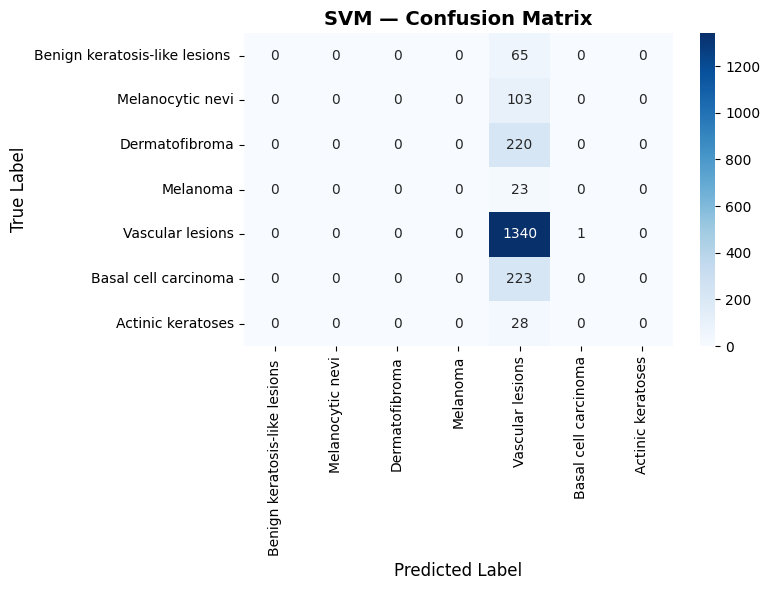


============ KNN — Confusion Matrix ============


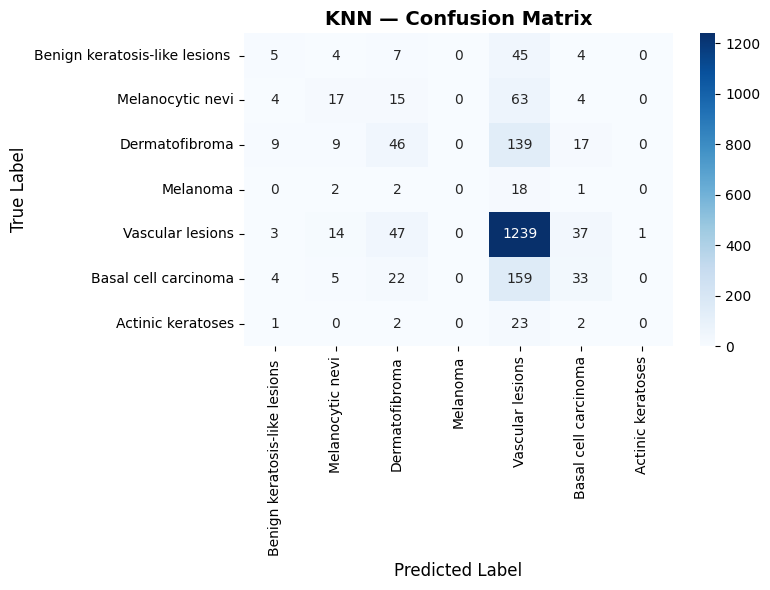


============ Decision Tree — Confusion Matrix ============


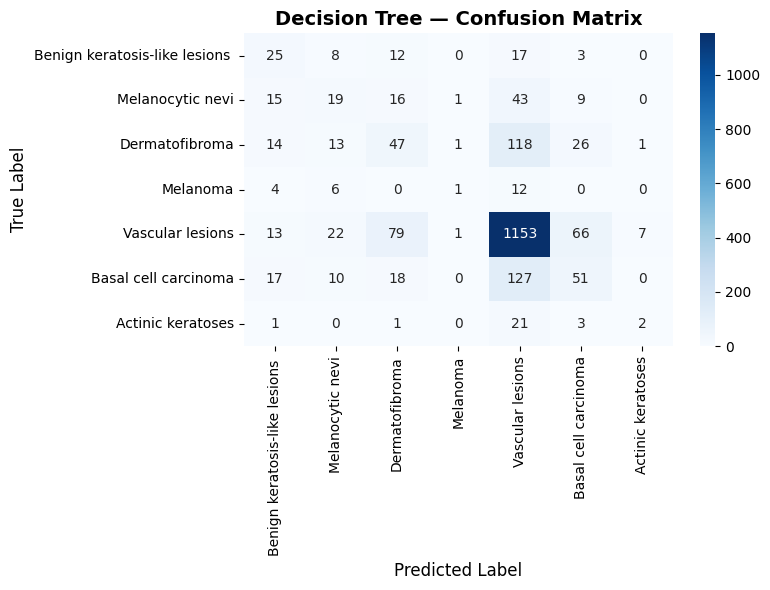

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    print(f"\n============ {name} — Confusion Matrix ============")

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=(class_names if 'class_names' in locals() else None),
                yticklabels=(class_names if 'class_names' in locals() else None))
    plt.title(f'{name} — Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

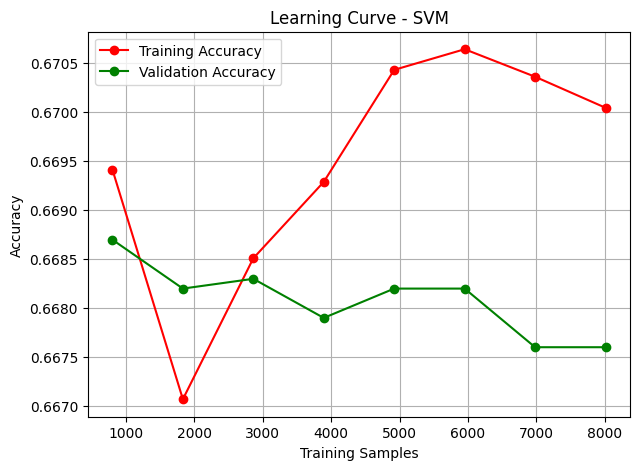

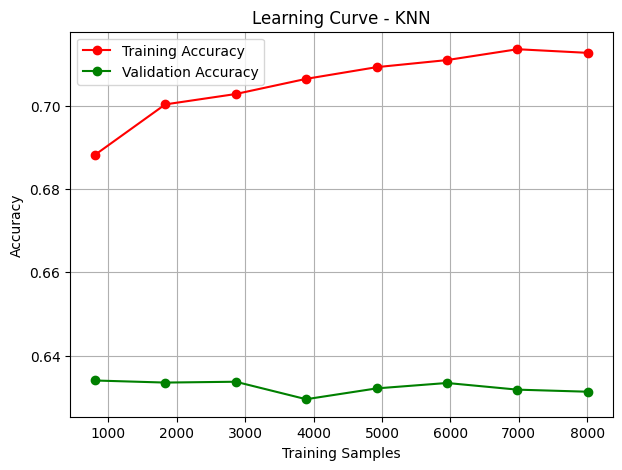

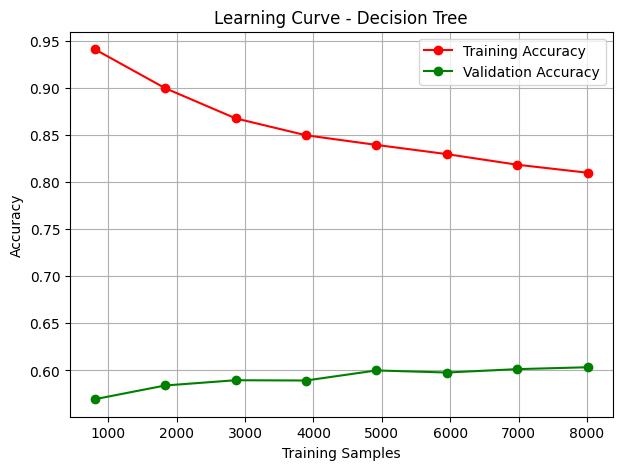

In [22]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_ml_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        train_sizes=np.linspace(0.1,1.0,8),
        scoring='accuracy',
        shuffle=True,
        random_state=42
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_mean, 'o-', label="Training Accuracy", color='red')
    plt.plot(train_sizes, val_mean, 'o-', label="Validation Accuracy", color='green')

    plt.title(f"Learning Curve - {title}")
    plt.xlabel("Training Samples")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

# Plot curves
plot_ml_curve(SVC(kernel='rbf', C=5, gamma='scale'), X, y, "SVM")
plot_ml_curve(KNeighborsClassifier(n_neighbors=10), X, y, "KNN")
plot_ml_curve(DecisionTreeClassifier(max_depth=10, random_state=42), X, y, "Decision Tree")

In [23]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize



==================== SVM — ROC Curve ====================
Macro AUC = 0.6111


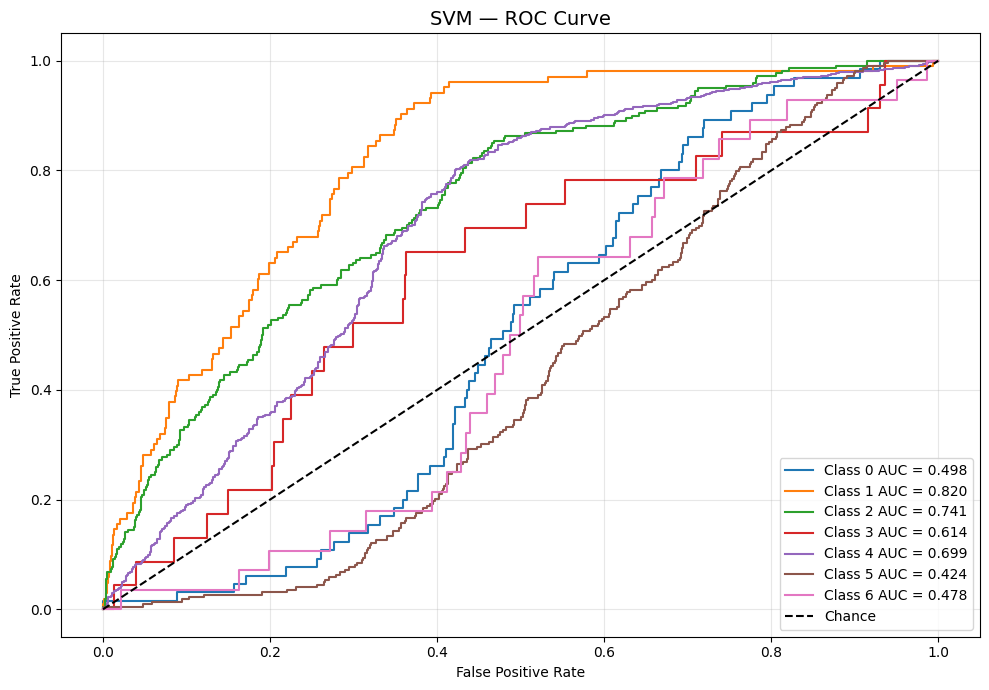



==================== KNN — ROC Curve ====================
Macro AUC = 0.6852


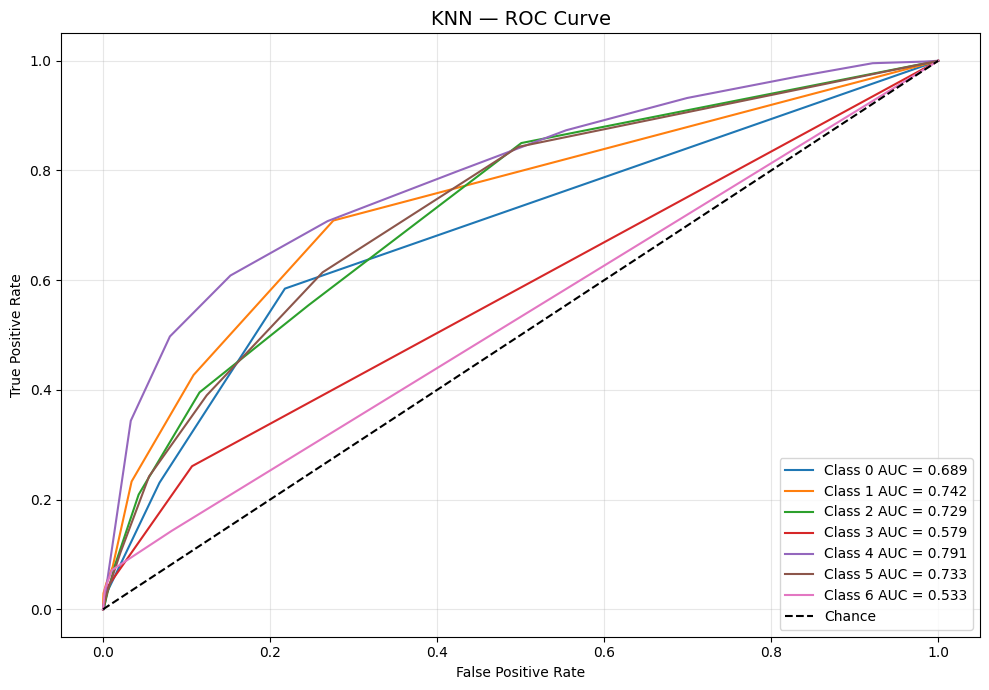



==================== Decision Tree — ROC Curve ====================
Macro AUC = 0.7072


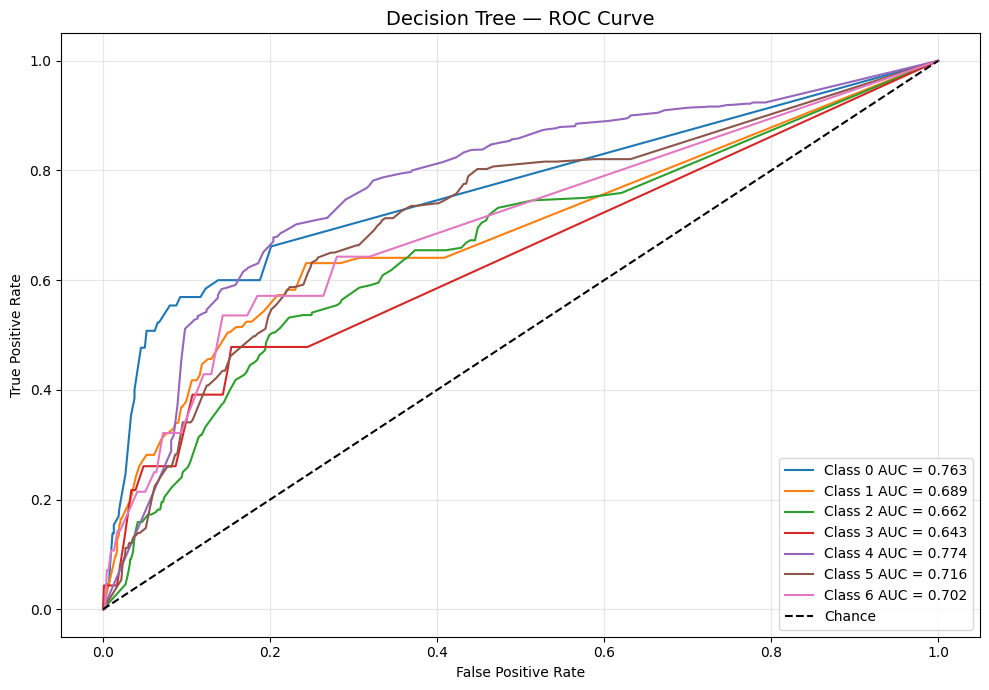

In [24]:
# ===== ROC / AUC FOR MULTICLASS =====

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

for name, model in models.items():
    print(f"\n\n==================== {name} — ROC Curve ====================")

    # Model prediction probabilities or decision function
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        # For SVM (no predict_proba) use decision function
        y_score = model.decision_function(X_test)

    # Compute ROC curve and AUC for each class
    fpr = {}
    tpr = {}
    roc_auc = {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute Macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    print(f"Macro AUC = {macro_auc:.4f}")

    # Plot ROC Curve
    plt.figure(figsize=(10, 7))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i],
                 label=f"Class {i} AUC = {roc_auc[i]:.3f}")

    plt.plot([0, 1], [0, 1], 'k--', label="Chance")
    plt.title(f"{name} — ROC Curve", fontsize=14)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
